In [1]:
from typing import Any

from kirin.ir import Method
import matplotlib.pyplot as plt
import numpy as np

from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
import matplotlib.pyplot as plt

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# this function will help us visualize some circuits
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
@squin.kernel
def steane_code_encoding(q):

    squin.h(q[4])
    squin.h(q[5])
    squin.h(q[6])

    squin.cx(q[0], q[1])
    squin.cx(q[0], q[2])

    squin.cx(q[6], q[0])
    squin.cx(q[6], q[1])
    squin.cx(q[6], q[3])

    squin.cx(q[5], q[0])
    squin.cx(q[5], q[2])
    squin.cx(q[5], q[3])

    squin.cx(q[4], q[3])
    squin.cx(q[4], q[2])
    squin.cx(q[4], q[1])

    return q

@squin.kernel
def steane_code_encoding_print():
    q = squin.qalloc(7)
    q = steane_code_encoding(q)
    return q

show_circuit(steane_code_encoding_print)

In [3]:
@squin.kernel
def logical_X(q):
    squin.broadcast.x(q)
    return q

@squin.kernel
def logical_Z(q):
    squin.broadcast.z(q)
    return q

@squin.kernel
def logical_Y(q):
    squin.broadcast.y(q)
    return q

@squin.kernel
def logical_H(q):
    squin.broadcast.h(q)
    return q

@squin.kernel
def logical_S(q):
    squin.broadcast.s_adj(q)
    return q

@squin.kernel
def logical_CX(control, target):
    #for i in range(7):
    #    squin.cx(control[i], target[i])
    squin.broadcast.cx(control, target)
    return control, target

@squin.kernel
def logical_T_injection(q):
    squin.h(q[0])
    squin.t(q[0])
    q = steane_code_encoding(q)
    return q

@squin.kernel
def logical_T_injection_print():
    q = squin.qalloc(7)
    q = logical_T_injection(q)
    return q

show_circuit(logical_T_injection_print)


In [4]:
@squin.kernel
def logical_T_teleportation(q, ancilla):
    
    ancilla = logical_T_injection(ancilla)
    
    for i in range(7):
        squin.cx(q[i], ancilla[i])

    bits = squin.broadcast.measure(ancilla)

    res = 0
    for b in bits:
        res ^= b

    if res == 1:
        q = logical_S(q)
    
    return q

In [5]:
@squin.kernel
def reference_t_gate(theta: float, phi: float):
    q = squin.qalloc(7)
    
    # 1. Arbitrary State Prep
    squin.ry(theta, q[0])
    squin.rz(phi, q[0])
    
    # 2. Physical T-Gate
    squin.t(q[0])
    
    q = steane_code_encoding(q)
    return q

In [6]:
@squin.kernel
def logical_t_gadget(theta: float, phi: float):

    data = squin.qalloc(7)
    ancilla = squin.qalloc(7)
    
    # 1. Arbitrary State Prep on Data[0]
    squin.ry(theta, data[0])
    squin.rz(phi, data[0])
    steane_code_encoding(data)

    data = logical_T_teleportation(data, ancilla)
        
    return data

In [7]:
theta = np.pi/4
phi = np.pi/3

reference_sim = StackMemorySimulator(min_qubits=7)
reference_task = reference_sim.task(reference_t_gate, args=(theta, phi))
reference_result = reference_task.run()
rho_reference = StackMemorySimulator.reduced_density_matrix(reference_result)
print(rho_reference)

logical_sim = StackMemorySimulator(min_qubits=7)
logical_task = logical_sim.task(logical_t_gadget, args=(theta, phi))
logical_result = logical_task.run()
rho_logical = StackMemorySimulator.reduced_density_matrix(logical_result)
print(rho_logical)

print("Do the two states match?", np.allclose(rho_reference, rho_logical))

[[ 0.10669408-0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
  -0.01143829-0.04268827j]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 ...
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [-0.01143829+0.04268827j  0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.01830582+0.j        ]]
[[ 0.10669417+0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
  -0.01143831-0.04268829j]
 [ 0.        +0.j    

In [8]:
import json

gridsynth_results = {}

with open("gridsynth_results.json", "r") as f:
    loaded_data = json.load(f)
    for k, v in loaded_data.items():
        gridsynth_results[eval(k)] = v

print("Loaded Gridsynth results:")
for key, value in gridsynth_results.items():
    print(f"n={key[0]}, eps={key[1]}: {value}")

Loaded Gridsynth results:
n=3, eps=0.1: SHTSHTHTSHTSHTSHTHTSHTHTSHTSHTSHTHTSHTSSWWWWW
n=3, eps=0.01: HTHTSHTHTSHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTHTSHSSW
n=3, eps=0.001: HTSHTSHTSHTHTHTHTHTHTHTSHTHTHTSHTSHTHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTSHTHTHTHTHTSHTHTHTHXSSWWWWW
n=3, eps=0.0001: HTHTHTSHTSHTHTHTHTHTSHTSHTHTHTHTHTSHTHTHTHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTHTSHTSW
n=3, eps=0.00001: HTSHTHTHTSHTSHTSHTSHTHTSHTSHTSHTHTSHTHTSHTHTHTSHTSHTSHTHTSHTHTSHTHTHTHTHTHTHTSHTHTSHTHTHTSHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTSHTHTHSSS
n=3, eps=0.000001: HTHTSHTHTHTHTSHTSHTHTSHTHTSHTSHTHTSHTSHTHTHTSHTHTSHTHTHTHTSHTHTHTSHTSHTHTSHTHTSHTHTSHTHTSHTHTHTHTHTSHTHTSHTSHTHTHTSHTSHTSHTHTHTHTHTHTSHTHTSHTSHTHTSHTHTSSSWWWWWWW
n=4, eps=0.1: SHTSHTHTHTHTHTSHTHTSHTSHTSHXSSWWWWWWW
n=4, eps=0.01: HTHTHTSHTHTSHTSHTSHTHTSHTSHTHTSHTHTHTSHTSHTSHTSHTHTSHXSSWWWW
n=4, eps=0.001: THTSHTSHTHTSHTSHTSHTSHTSHTHTHTSHTSHTHTSHTHTSHTHTHTHTSHTHTHTSHTHTSHTHTSHTSHTHTHTSHTSHTHXSSS
n=4, eps=0.0001: SHTSHTHTSHTHTHTHTHTSHTHTHTSH

In [9]:
import numpy as np
from utils import density_matrix_fidelity

epsilons = sorted(set(eps for _, eps in gridsynth_results.keys()))

# Removed 'repeated_trials'
metrics_names = [
    "fidelity",
    "ancilla_count",
    "2_qubit_gate_count",
    "feed_forward",
    "circuit_depth",
    "success_probability", 
]

metrics = {metric: {} for metric in metrics_names}

@squin.kernel
def plus_reference():
    q = squin.qalloc(7)
    squin.h(q[0])
    q = steane_code_encoding(q)
    return q

reference_sim = StackMemorySimulator(min_qubits=7)
reference_task = reference_sim.task(plus_reference)
reference_result = reference_task.run()
rho_reference = StackMemorySimulator.reduced_density_matrix(reference_result)

for n, _ in gridsynth_results.keys():

    theta = np.pi / 2**n

    for eps in epsilons:

        gates = gridsynth_results.get((n, eps))
        
        # --- METRICS CALCULATIONS ---
        num_T = gates.count("T")
        
        ancilla_count = 7 * num_T
        cnot_count = 9 + (16 * num_T)
        feed_forward_count = num_T
        logical_depth = len(gates) + 1
        
        # POST-SELECTION MATH:
        # 50% success rate per T-gate. 
        # All T-gates must succeed for the sequence to be kept.
        success_prob = 0.5 ** num_T
        # -----------------------------

        @squin.kernel
        def synthesized_gate():
            q = squin.qalloc(7)
            ancilla = squin.qalloc(7)
            squin.h(q[0])
            squin.rz(-theta, q[0])
            q = steane_code_encoding(q)
            for gate in gates:
                if gate[0] == "H":
                    q = logical_H(q)
                elif gate[0] == "S":
                    q = logical_S(q)
                elif gate[0] == "T":
                    q = logical_T_teleportation(q, ancilla)
                elif gate[0] == "X":
                    q = logical_X(q)
                elif gate[0] == "Y":
                    q = logical_Y(q)
                elif gate[0] == "Z":
                    q = logical_Z(q)
                squin.broadcast.reset(ancilla)
            return q
        
        synthesized_sim = StackMemorySimulator(min_qubits=7)
        synthesized_task = synthesized_sim.task(synthesized_gate)
        synthesized_result = synthesized_task.run()
        rho_synthesized = StackMemorySimulator.reduced_density_matrix(synthesized_result)

        fidelity = density_matrix_fidelity(rho_reference, rho_synthesized)
        
        # --- STORE ALL METRICS ---
        metrics["fidelity"][(n, eps)] = fidelity
        metrics["ancilla_count"][(n, eps)] = ancilla_count
        metrics["2_qubit_gate_count"][(n, eps)] = cnot_count
        metrics["feed_forward"][(n, eps)] = feed_forward_count
        metrics["circuit_depth"][(n, eps)] = logical_depth
        metrics["success_probability"][(n, eps)] = success_prob

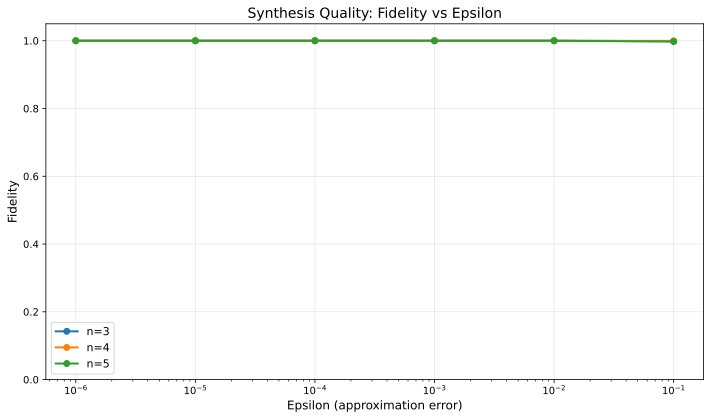

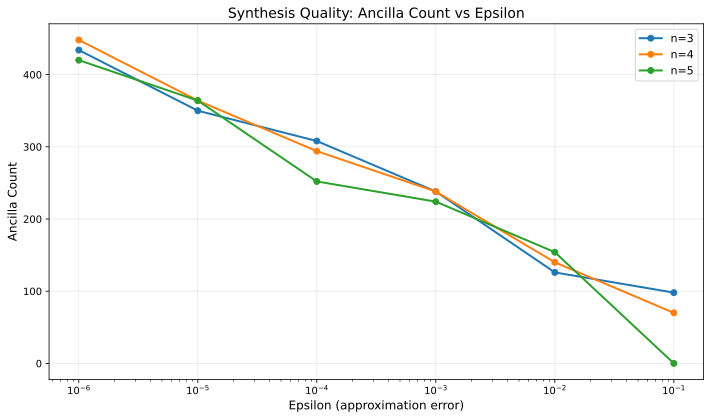

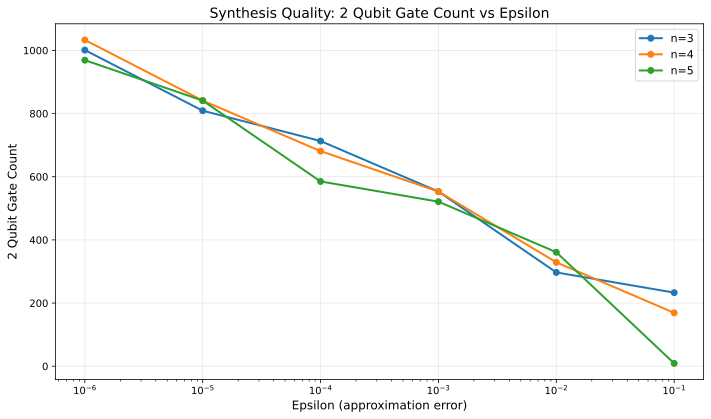

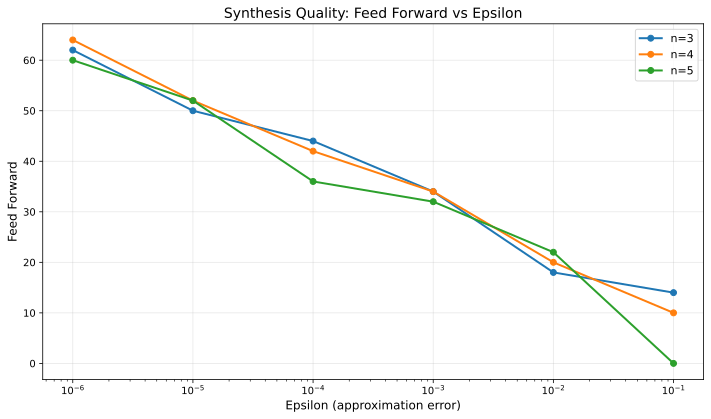

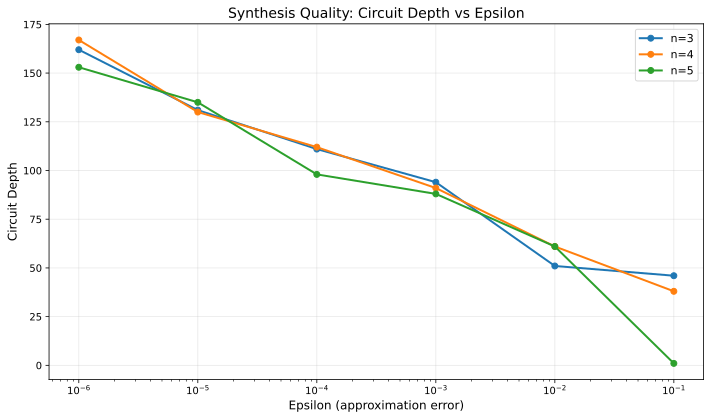

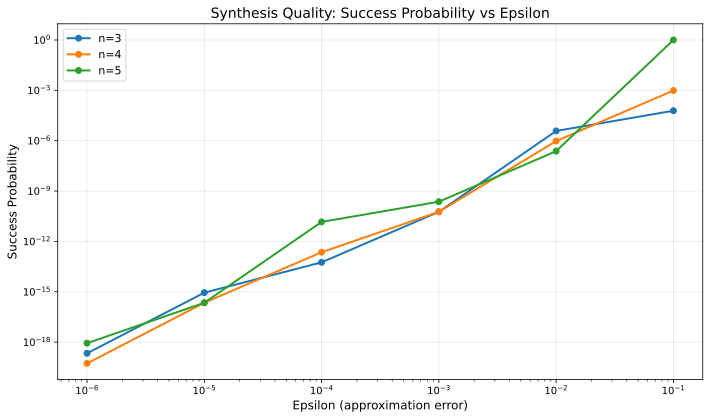

All plots completed!


In [10]:
import matplotlib.pyplot as plt

for metric in metrics_names:
    
    grouped_data = {}
    
    if metric not in metrics or not metrics[metric]:
        continue
        
    for (n, eps), value in metrics[metric].items():
        eps_float = float(eps)
        if n not in grouped_data:
            grouped_data[n] = []
        grouped_data[n].append((eps_float, value))

    plt.figure(figsize=(10, 6))

    for n_val in sorted(grouped_data.keys()):
        sorted_pairs = sorted(grouped_data[n_val], key=lambda x: x[0])
        
        eps_vals = [pair[0] for pair in sorted_pairs]
        val_vals = [pair[1] for pair in sorted_pairs]
        
        plt.plot(eps_vals, val_vals, marker="o", label=f"n={n_val}", linewidth=2, markersize=6)

    formatted_title = metric.replace("_", " ").title()
    
    plt.xlabel("Epsilon (approximation error)", fontsize=12)
    plt.ylabel(formatted_title, fontsize=12)
    plt.title(f"Synthesis Quality: {formatted_title} vs Epsilon", fontsize=14)
    plt.xscale("log")
    
    # For success probability, using a log scale on the Y-axis might make 
    # the exponential decay much easier to read! Let's allow it to dynamically scale,
    # except for fidelity which we keep locked between 0 and 1.
    if metric == "fidelity":
        plt.ylim([0, 1.05])
    elif metric == "success_probability":
        plt.yscale("log") # Exponential decay is best viewed on a log-log plot
        
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

print("All plots completed!")

In [11]:
import cirq

def steane_encode(q):
    """Yields the operations to encode q[0] into the 7-qubit Steane code."""
    yield cirq.CX(q[0], q[1])
    yield cirq.CX(q[0], q[2])
    yield cirq.H.on_each(q[3], q[4], q[5])
    
    yield cirq.CX(q[3], q[1])
    yield cirq.CX(q[3], q[2])
    yield cirq.CX(q[3], q[6])
    
    yield cirq.CX(q[4], q[0])
    yield cirq.CX(q[4], q[2])
    yield cirq.CX(q[4], q[6])
    
    yield cirq.CX(q[5], q[0])
    yield cirq.CX(q[5], q[1])
    yield cirq.CX(q[5], q[6])

def logical_H(q):
    yield cirq.H.on_each(*q)

def logical_S(q):
    # Remember: physical S-dagger implements logical S in Steane code!
    yield (cirq.S**-1).on_each(*q) 
    
def logical_X(q):
    yield cirq.X.on_each(*q)

In [12]:
import cirq
import sympy

def logical_T_teleportation(data_qubits, ancilla_qubits, measurement_key_prefix):
    # 1. Prepare Ancilla in Magic State
    yield cirq.H(ancilla_qubits[0])
    yield cirq.T(ancilla_qubits[0])
    yield from steane_encode(ancilla_qubits)
    
    # 2. Transversal CNOT (Data acts as control, Ancilla as target)
    for i in range(7):
        yield cirq.CX(data_qubits[i], ancilla_qubits[i])
        
    # 3. Measure the Ancilla block
    meas_keys = [f"{measurement_key_prefix}_{i}" for i in range(7)]
    for i in range(7):
        yield cirq.measure(ancilla_qubits[i], key=meas_keys[i])
        
    # 4. Correct Conditional Feed-Forward using SymPy
    # Create a sympy symbol for each measurement key
    symbols = [sympy.Symbol(k) for k in meas_keys]
    
    # Parity condition: (meas_0 + meas_1 + ... + meas_6) % 2
    # This evaluates to 1 (True) if odd, and 0 (False) if even.
    parity_condition = sympy.Mod(sum(symbols), 2)
        
    # Apply S-dagger to all data qubits conditionally
    for q in data_qubits:
        yield (cirq.S**-1).on(q).with_classical_controls(parity_condition)
        
    # 5. Reset Ancillas so they can be reused for the next T-gate
    yield cirq.ResetChannel().on_each(*ancilla_qubits)

In [ ]:
# 1. Allocate Qubits
data = cirq.LineQubit.range(7)
ancilla = cirq.LineQubit.range(7, 14)

# 2. Build the Ideal Circuit
circuit = cirq.Circuit()

# Arbitrary State Prep (e.g., pi/8 rotation)
circuit.append(cirq.H(data[0]))
circuit.append(cirq.rz(np.pi/8)(data[0]))

# Encode
circuit.append(steane_encode(data))

# Apply a synthesized sequence (e.g., "HTS")
circuit.append(logical_H(data))
circuit.append(logical_T_teleportation(data, ancilla, "T1"))
circuit.append(logical_S(data))

# 3. Apply the Noise Model
# Example: 0.1% depolarizing noise on every gate
noise_model = cirq.depolarize(p=0.001)
noisy_circuit = circuit.with_noise(noise_model)

# 4. Simulate using the Density Matrix Simulator
sim = cirq.DensityMatrixSimulator()
result = sim.simulate(noisy_circuit)